### Graph Neural Network (GNN)

Drugs = Nodes in a graph
Known interactions = Edges between nodes
Features = Chemical properties (fingerprints, functional groups, physicochemical)
Task: Link prediction (will there be an edge between two nodes?)

## **Pipeline summary**

| Aspect | What you have |
|--------|----------------|
| **Data** | DrugBank DDI + SMILES; multi-view (Morgan, MACCS, phys-chem); stratified 70/15/15 train/val/test. |
| **Model** | Multi-view attention → GATv2 (2 layers) → edge classifier (binary + type); fits subgraph-based, memory-efficient training. |
| **Training** | Priority 1: Full-graph GNN once/epoch + edge-only batches (no k_hop per batch). AMP, graph on GPU, validate every N epochs, optional torch.compile. |
| **Metrics** | Validation: loss, accuracy, F1, precision, recall; test: same + ROC-AUC. |

The Pipeline in 5 Steps
```bash
1. FEATURE EXTRACTION
   Raw SMILES → Morgan FP + MACCS + Properties
   
2. GRAPH CONSTRUCTION
   Build adjacency matrix (who interacts with whom)
   
3. MULTI-VIEW FUSION
   Combine 3 views using attention
   
4. GNN ENCODING
   Message passing to learn node embeddings
   
5. EDGE CLASSIFICATION
   Predict interaction from node pair embeddings
```

### Metrices

- **Accuracy** (with a 0.90 target)
- **F1**
- **Precision**
- **Recall** (for “don’t miss DDIs”)
- **ROC-AUC**
to get a single, comparable test report for accuracy and F1/recall.

If you share your current test accuracy and F1/recall after one full run (with the Neg fix and new config), we can suggest next steps (e.g. one more GAT layer, dropout, or label smoothing) to push toward 90% while keeping the pipeline memory-efficient and fast.

## 1. Importing Libraries and Dependencies

In [1]:
import gc
import time
import json
import os
import numpy as np
import pandas as pd
from datetime import timedelta, datetime
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Graph & Geometry
from torch_geometric.nn import GATv2Conv, GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import k_hop_subgraph
from torch.amp import GradScaler, autocast
from safetensors.torch import save_model as save_safetensors, load_model as load_safetensors

# Molecular Processing
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors, MACCSkeys

# Metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, precision_recall_curve, auc, confusion_matrix

## 2. System Setup

In [2]:
# Runtime Optimization
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"● DEVICE: {DEVICE}")
DEVICE_TYPE = DEVICE.type
# Aggressive memory management
if DEVICE_TYPE == 'cuda':
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    # Force garbage collection
    gc.collect()
    print(f"- GPU: {torch.cuda.get_device_name(0)}")
    print(f"- GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    print("- ✓ Memory optimization enabled")

# Clear CUDA Cache
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    # Set Allocator Strategy to reduce fragmentation
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    print(f"- GPU Memory Freed. Allocated: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
    print(f"- Reserved: {torch.cuda.memory_reserved()/1024**2:.2f} MB")
else:
    print("-Running on CPU (No CUDA clear needed)")

TIMESTAMP = datetime.now().strftime("%d_%b_%H-%M")

# validating artifact directories:
required_directories = ['images', 'models']
for folder in required_directories:
    if not os.path.exists(folder):
        print(f"✘ Directory `{folder}/` not found \nCreating...")
        os.makedirs(folder)
    else:
        print(f"✓ Directory `{folder}/` exists")

● DEVICE: cuda
- GPU: NVIDIA GeForce GTX 1650
- GPU Memory: 4.00 GB
- ✓ Memory optimization enabled
- GPU Memory Freed. Allocated: 0.00 MB
- Reserved: 0.00 MB
✓ Directory `images/` exists
✓ Directory `models/` exists


### 2.2 Path Configurations

In [3]:
DDIS_DATA_PATH = 'dataset/drugdata/ddis.csv'
DRUG_SMILE_DATA_PATH = 'dataset/drugdata/drug_smiles.csv'
# DDIS_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/ddis.csv'
# DRUG_SMILE_DATA_PATH = 'https://raw.githubusercontent.com/Adya-Prasad/AushadhiNet/refs/heads/main/dataset/drugdata/drug_smiles.csv'
MODEL_WEIGHT_PATH = f"models/AushadiNet_GATv2-128_{TIMESTAMP}"
MODEL_METADATA_PATH = f"models/AushadiNet_GATv2-metadata_{TIMESTAMP}"

## 3. Parameters Configurations
- Small physical batch → Fits in memory
- Large effective batch → Better training stability
- This technique is used in GPT-3, BERT, and all large models!

In [4]:
CONFIG = {
    # Increased model capacity
    "physical_batch_size": 512,
    "accumulation_steps": 4,
    "hidden_dim": 384,           # Increased from 256
    "n_heads": 6,                # Increased from 4
    "dropout": 0.25,             # Slightly reduced
    "n_gat_layers": 3,           # Add 3rd GAT layer
    
    # Better training dynamics
    "lr": 3e-4,                  # Lower LR for fine-tuning
    "weight_decay": 5e-5,        # Reduced regularization
    "epochs": 10,               # More epochs
    
    # Loss configuration
    "type_loss_weight": 0.3,     # Reduced (focus on binary first)
    "use_class_weights": True,
    "focal_loss": True,          # Use focal loss for hard examples
    "focal_alpha": 0.7,          # Weight for positive class
    "focal_gamma": 2.0,          # Focus on hard examples
    
    # Scheduler
    "scheduler_patience": 7,     # More patience
    "scheduler_factor": 0.5,
    "min_lr": 1e-6,
    
    # System
    "full_graph_on_gpu": True,
    "validate_every_n_epochs": 2,
    "use_compile": True,        # Disable if Triton issues
    
    # Data augmentation
    "edge_dropout_rate": 0.05,   # Reduced
    "feature_noise": 0.005,      # Reduced
}
 
print(f"✓ Configurations set")

✓ Configurations set


## 4. Reading Dataset

In [5]:
# Load DDI data
def read_data(ddi_path: str = DDIS_DATA_PATH, smiles_path: str = DRUG_SMILE_DATA_PATH):
    """Load raw DDI and SMILES tables from disk."""
    ddi_df = pd.read_csv(ddi_path)
    smiles_df = pd.read_csv(smiles_path)
    print("✓ Data loaded successfully")
    print("● DDI shape:", ddi_df.shape)
    unique_drugs_ddi = set(ddi_df['d1'].unique()) | set(ddi_df['d2'].unique())
    print(f"• Total DDI pairs: {len(ddi_df)}")
    print(f"• Unique drugs in DDI: {len(unique_drugs_ddi)}")
    print(f"• Drugs with SMILES: {len(smiles_df)}")
    print(f"• Drug Pair Interaction type 0: {(ddi_df['type'] == 0).sum()}")
    print(f"• Drug Pair Interaction type 7: {(ddi_df['type'] == 7).sum()}")
    print("● SMILES shape:", smiles_df.shape)
    print("● DDI columns:", ddi_df.columns.tolist())
    print("● SMILES columns:", smiles_df.columns.tolist())
    drugs_with_smiles = set(smiles_df['drug_id'].unique())
    overlap = unique_drugs_ddi & drugs_with_smiles
    print(f"• Drugs with both DDI and SMILES: {len(overlap)}")
    print(f"• Coverage: {len(overlap)/len(unique_drugs_ddi)*100:.2f}%")

    return ddi_df, smiles_df


def quick_sanity_report(ddi_df: pd.DataFrame, smiles_df: pd.DataFrame):
    """Print a compact sanity report (non‑destructive)."""
    print("\nⓘ QUICK SANITY REPORT:\n")

    # DDI
    print("[1. DDI Data: Interaction pairs]")
    print("● Total rows:", len(ddi_df))
    print("● nulls per column:", ddi_df.isnull().sum().to_dict())
    if {"d1", "d2", "type"}.issubset(ddi_df.columns):
        print("● Total interactions types:", ddi_df["type"].nunique())
        print("● Top `type` distribution (top 10):")
        print(ddi_df["type"].value_counts().head(10))

    # SMILES
    print("\n[2. SMILES Data: Molecular Structures]")
    print("● Total rows:", len(smiles_df))
    print("● Checking nulls per column?:", smiles_df.isnull().sum().to_dict())

    # Overlap
    ddi_drugs = set(ddi_df["d1"]).union(set(ddi_df["d2"]))
    smiles_drugs = set(smiles_df["drug_id"]) if "drug_id" in smiles_df.columns else set()
    overlap = ddi_drugs & smiles_drugs
    print(f"\n● Overlap: {len(overlap)}/{len(ddi_drugs)} DDI drugs have SMILES ({100*len(overlap)/len(ddi_drugs):.2f}%)")


# Load once (reused later)
ddi_df, smiles_df = read_data()
quick_sanity_report(ddi_df, smiles_df)

✓ Data loaded successfully
● DDI shape: (191808, 4)
• Total DDI pairs: 191808
• Unique drugs in DDI: 1706
• Drugs with SMILES: 1706
• Drug Pair Interaction type 0: 11
• Drug Pair Interaction type 7: 244
● SMILES shape: (1706, 2)
● DDI columns: ['d1', 'd2', 'type', 'Neg samples']
● SMILES columns: ['drug_id', 'smiles']
• Drugs with both DDI and SMILES: 1706
• Coverage: 100.00%

ⓘ QUICK SANITY REPORT:

[1. DDI Data: Interaction pairs]
● Total rows: 191808
● nulls per column: {'d1': 0, 'd2': 0, 'type': 0, 'Neg samples': 0}
● Total interactions types: 86
● Top `type` distribution (top 10):
type
48    60751
46    34360
72    23779
74     9470
59     8397
69     7786
19     6140
15     5413
3      5011
5      3160
Name: count, dtype: int64

[2. SMILES Data: Molecular Structures]
● Total rows: 1706
● Checking nulls per column?: {'drug_id': 0, 'smiles': 0}

● Overlap: 1706/1706 DDI drugs have SMILES (100.00%)


## 5. Feature Extraction

Why Multiview? Different views capture different aspects:
1. View 1 (Morgan FP): Substructure patterns. Good for structural similarity
2. View 2 (MACCS Keys): Functional groups. Good for functional groups (OH, COOH, etc.)
3. View 3 (Properties): Physical/chemical behavior. Good for metabolism.

### Deep Dive: Morgan Fingerprints
Imagine walking from each atom:

- Start at atom A
- Walk 2 steps in all directions
- Record what you see: "carbon-nitrogen-oxygen pattern"
- Hash this pattern → 1 bit in 1024-bit vector
- Repeat for all atoms

> Result: Binary vector capturing local substructures

`Why radius=2?`
- Radius 1: Too local (just immediate bonds)
- Radius 2: Good balance (captures small functional groups)
- Radius 3: Too broad (high memory, diminishing returns)

`Why fpSize=1024?`- 

- Smaller (512): More collisions (different patterns → same bit)
- 1024: Good balance
- Larger (2048): Sparse, high memory

`What are MACCS Keys?` Predefined 166 structural patterns (keys):
- Key 1: "Has O atom?"
- Key 50: "Has aromatic ring?"
- Key 120: "Has carboxylic acid group?"

In [6]:
class DrugFeatureExtractor:
    """
    Extracting diverse 'multiviews' of the same molecule.
    View 1: Morgan FP (Detailed Substructure)
    View 2: MACCS Keys (Functional Groups)
    View 3: Physico-Chemical Properties (Global Properties)
    """
    def __init__(self):
        self.morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
        
    def get_features(self, smiles_df):
        view1_morgan = []
        view2_maccs = []
        view3_phys = []
        valid_ids = []
        
        print("● Extracting Multi-View Features...")
        
        for _, row in smiles_df.iterrows():
            mol = Chem.MolFromSmiles(str(row["smiles"]))
            if mol:
                # View 1: Morgan Fingerprint (1024 dim)
                fp = np.array(self.morgan_gen.GetFingerprint(mol), dtype=np.float32)
                
                # View 2: MACCS Keys (167 dim) - Great for functional groups
                maccs = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
                
                # View 3: Physico-chemical 8 properties (8 dim) - Great for transport/metabolism
                desc = np.array([
                    Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                    Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol),
                    Descriptors.TPSA(mol), Descriptors.NumRotatableBonds(mol),
                    Descriptors.NumAromaticRings(mol), Descriptors.FractionCSP3(mol)
                ], dtype=np.float32)
                
                view1_morgan.append(fp)
                view2_maccs.append(maccs)
                view3_phys.append(desc)
                valid_ids.append(row["drug_id"])
        
        # Stack and Normalize View 3 (since it has large values like Weight)
        v1 = np.stack(view1_morgan)
        v2 = np.stack(view2_maccs)
        v3 = np.stack(view3_phys)
        
        scaler = StandardScaler()
        v3 = scaler.fit_transform(v3)
        
        print(f"✓ Processed {len(valid_ids)} drugs.")
        print(f"  - View 1 Shape: {v1.shape}")
        print(f"  - View 2 Shape: {v2.shape}")
        print(f"  - View 3 Shape: {v3.shape}")
        
        return {
            "v1": torch.tensor(v1, dtype=torch.float),
            "v2": torch.tensor(v2, dtype=torch.float),
            "v3": torch.tensor(v3, dtype=torch.float),
            "ids": valid_ids
        }

# Load and Process
smiles_df = pd.read_csv(DRUG_SMILE_DATA_PATH)
extractor = DrugFeatureExtractor()
features_dict = extractor.get_features(smiles_df)

● Extracting Multi-View Features...
✓ Processed 1706 drugs.
  - View 1 Shape: (1706, 1024)
  - View 2 Shape: (1706, 167)
  - View 3 Shape: (1706, 8)


## 6. Data Augmentation

In [7]:
class DDIDataAugmenter:
    """
    Augment training data to improve generalization:
    1. Edge dropout (random edge masking)
    2. Feature perturbation
    3. Hard negative mining
    """    
    @staticmethod
    def augment_graph_training(graph, edge_dropout=0.1, feature_noise=0.01):
        """
        Apply augmentation during training epoch.
        """
        # Edge dropout: Randomly remove edges from adjacency
        if edge_dropout > 0:
            mask = torch.rand(graph['edge_index'].shape[1]) > edge_dropout
            aug_edge_index = graph['edge_index'][:, mask]
        else:
            aug_edge_index = graph['edge_index']
        
        # Feature noise: Add small Gaussian noise
        if feature_noise > 0:
            aug_x_v1 = graph['x_v1'] + torch.randn_like(graph['x_v1']) * feature_noise
            aug_x_v2 = graph['x_v2'] + torch.randn_like(graph['x_v2']) * feature_noise
            aug_x_v3 = graph['x_v3'] + torch.randn_like(graph['x_v3']) * feature_noise
        else:
            aug_x_v1, aug_x_v2, aug_x_v3 = graph['x_v1'], graph['x_v2'], graph['x_v3']
        
        return {
            'edge_index': aug_edge_index,
            'x_v1': aug_x_v1,
            'x_v2': aug_x_v2,
            'x_v3': aug_x_v3
        }

## 7. Data Split and Graph Construction
Converting tabular data (CSV) → Graph structure (PyG format)


In [8]:
class GraphBuilder:
    def __init__(self, ddi_path, feature_dict):
        self.ddi_df = pd.read_csv(ddi_path)
        self.feats = feature_dict
        self.drug_map = {d: i for i, d in enumerate(feature_dict['ids'])}
        self.idx_map = {i: d for d, i in self.drug_map.items()}
        self.type_enc = LabelEncoder()
        
    def build(self):
        # Map Edges
        pos_src, pos_dst, pos_types = [], [], []
        neg_src, neg_dst = [], []
        
        print("● Building DDI Graph Topology...")
        for _, row in self.ddi_df.iterrows():
            if row['d1'] in self.drug_map and row['d2'] in self.drug_map:
                u, v = self.drug_map[row['d1']], self.drug_map[row['d2']]
                
                # Bidirectional Positive Edge
                # Because If A interacts with B, then B interacts with A
                pos_src.extend([u, v])
                pos_dst.extend([v, u])
                pos_types.extend([row['type'], row['type']])
                
                # Negative Edge Handling: "DRUGID$t" or "DRUGID$h" -> extract DRUGID only
                if isinstance(row['Neg samples'], str):
                    neg_raw = row['Neg samples'].strip().split('$')[0]
                    if neg_raw and neg_raw in self.drug_map:
                        w = self.drug_map[neg_raw]
                        neg_src.extend([u, w])
                        neg_dst.extend([w, u])

        # Convert to Tensors
        pos_edge_index = torch.tensor([pos_src, pos_dst], dtype=torch.long)
        neg_edge_index = torch.tensor([neg_src, neg_dst], dtype=torch.long)
        
        # Combine for processing
        full_edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
        
        # Label Encoding: Encode Types
        # Original: ["metabolism", "toxicity", "bleeding"]
        # Encoded:  [48, 46, 19]
        y_types_enc = self.type_enc.fit_transform(pos_types)
        
        # Create Labels
        # Binary: 1 for pos, 0 for neg
        y_binary = torch.cat([torch.ones(pos_edge_index.shape[1]), torch.zeros(neg_edge_index.shape[1])]).long()
        # Type: Encoded for pos, -1 for neg
        y_type = torch.cat([torch.tensor(y_types_enc), torch.full((neg_edge_index.shape[1],), -1)]).long()
        
        return {
            "x_v1": self.feats['v1'],
            "x_v2": self.feats['v2'],
            "x_v3": self.feats['v3'],
            "edge_index": full_edge_index,
            "y_binary": y_binary,
            "y_type": y_type,
            "n_types": len(self.type_enc.classes_),
            "encoder": self.type_enc,
            "drug_map": self.drug_map
        }

    def create_stratified_split(self, graph):
        # Stratified Split based on Binary Labels to ensure Negatives are balanced in Train/Val
        print("● Creating Stratified Splits (TDCommons Standard)...")
        n_edges = graph['edge_index'].shape[1]
        indices = np.arange(n_edges)
        
        train_idx, temp_idx = train_test_split(
            indices, test_size=0.3, stratify=graph['y_binary'], random_state=42
        )
        val_idx, test_idx = train_test_split(
            temp_idx, test_size=0.5, stratify=graph['y_binary'][temp_idx], random_state=42
        )
        
        # Create Boolean Masks
        for name, idx in zip(['train', 'val', 'test'], [train_idx, val_idx, test_idx]):
            mask = torch.zeros(n_edges, dtype=torch.bool)
            mask[idx] = True
            graph[f'{name}_mask'] = mask
            
        print(f"  - Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
        return graph

builder = GraphBuilder(DDIS_DATA_PATH, features_dict)
graph_data = builder.build()
graph = builder.create_stratified_split(graph_data)

● Building DDI Graph Topology...
● Creating Stratified Splits (TDCommons Standard)...
  - Train: 537062 | Val: 115085 | Test: 115085


## Helper functions: Plotting and Visualization


In [9]:
def plot_training_dashboard(history):

    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Training Metrics Overview", fontsize=16)

    # 1️⃣ Training Loss (Blue)
    axes[0, 0].plot(epochs, history['train_loss'], color='royalblue')
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].grid(True)

    # 2️⃣ Validation Accuracy (Green)
    axes[0, 1].plot(epochs, history['val_acc'], color='seagreen')
    axes[0, 1].set_title("Validation Accuracy")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].grid(True)

    # 3️⃣ Validation F1 Score (Orange)
    axes[1, 0].plot(epochs, history['val_f1'], color='darkorange')
    axes[1, 0].set_title("Validation F1-Score")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("F1-Score")
    axes[1, 0].grid(True)

    # 4️⃣ Validation Precision (Crimson)
    axes[1, 1].plot(epochs, history['val_precision'], color='crimson')
    axes[1, 1].set_title("Validation Precision")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

Architecture Overview:
```
Input: 3 Views (Morgan, MACCS, Properties)
  ↓
[Projection Layers] → All views to same dimension
  ↓
[Attention Fusion] → Learn which view is most important
  ↓
[GAT Layer 1] → Message passing (2 heads)
  ↓
[GAT Layer 2] → Second round of message passing
  ↓
[Edge Classifier] → Predict interaction from node pairs
  ↓
Output: [Binary: interact?, Type: which type?]
```
### Edge Classifier: How edge prediction works:
```
Question: Do Drug A and Drug B interact?

Step 1: Get their embeddings
  emb_A = [0.2, 0.5, 0.1, ...]  (256-dim)
  emb_B = [0.8, 0.3, 0.9, ...]  (256-dim)

Step 2: Concatenate
  edge_feat = [emb_A, emb_B]  (512-dim)

Step 3: Pass through MLP
  hidden = MLP(edge_feat)  (256-dim)

Step 4: Predict
  binary = Linear(hidden)  (2-dim: [no_interact, interact])
  type = Linear(hidden)    (86-dim: which type?)
```

## 8. GATv2 Neural Network Architecture

In [10]:
class FeatureAttentionLayer(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.atten = nn.Linear(dim, 1)
        
    def forward(self, v1, v2, v3):
        stack = torch.stack([v1, v2, v3], dim=1)
        scores = F.softmax(self.atten(stack), dim=1)
        fused = torch.sum(stack * scores, dim=1)
        return fused, scores

class GATv2NN(nn.Module):
    """
    Improvements:
    1. Residual connections for better gradient flow
    2. Layer normalization for training stability
    3. Edge dropout for regularization
    4. Optional feature masking
    """
    def __init__(self, dims, hidden_dim, n_heads, n_types, dropout=0.3):
        super().__init__()
        
        # View Projectors with BatchNorm
        self.proj_v1 = nn.Sequential(
            nn.Linear(dims['v1'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v2 = nn.Sequential(
            nn.Linear(dims['v2'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        self.proj_v3 = nn.Sequential(
            nn.Linear(dims['v3'], hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5)
        )
        
        # Feature Attention
        self.feat_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, 1)
        )
        
        # GATv2 Layers with residual connections
        self.gat1 = GATv2Conv(
            hidden_dim, hidden_dim // n_heads, 
            heads=n_heads, concat=True, dropout=dropout
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        
        self.gat2 = GATv2Conv(
            hidden_dim, hidden_dim, 
            heads=1, concat=False, dropout=dropout
        )
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.gat3  = GATv2Conv(
            hidden_dim, hidden_dim,
            heads=1, concat=False, dropout=dropout
        ) 
        self.norm3 = nn.LayerNorm(hidden_dim)
        
        # Edge Classifier with deeper network
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
        )
        
        self.head_bin = nn.Linear(hidden_dim // 2, 2)
        self.head_type = nn.Linear(hidden_dim // 2, n_types)
        
        self.dropout = dropout

        print("Model Intialized")

    def get_node_embeddings(self, x_v1, x_v2, x_v3, edge_index):
        """
        Full-graph forward with residual connections and normalization.
        """
        # Project each view
        h1 = self.proj_v1(x_v1)
        h2 = self.proj_v2(x_v2)
        h3 = self.proj_v3(x_v3)
        
        # Multi-view attention fusion
        stack = torch.stack([h1, h2, h3], dim=1)  # (N, 3, hidden_dim)
        scores = F.softmax(self.feat_attention(stack), dim=1)
        h_fused = torch.sum(stack * scores, dim=1)
        
        # GAT Layer 1 with residual
        h_gat1 = self.gat1(h_fused, edge_index)
        h_gat1 = self.norm1(h_gat1 + h_fused)  # Residual connection
        h_gat1 = F.elu(h_gat1)
        
        # GAT Layer 2 with residual
        h_gat2 = self.gat2(h_gat1, edge_index)
        node_emb = self.norm2(h_gat2 + h_fused)  # Skip connection to fusion

        # GAT Layer 3 with residual
        h_gat3 = self.gat3(node_emb, edge_index)
        node_emb = self.norm3(h_gat3 + h_fused)
        
        return node_emb

        # : Remove edge dropout for now
    def forward_edges_from_emb(self, node_emb, edge_label_index):
        src, dst = edge_label_index[0], edge_label_index[1]
        # edge operator
        edge_feat = torch.cat([node_emb[src], node_emb[dst]], dim=-1)
        shared = self.edge_encoder(edge_feat)  # or self.classifier if using original model
        return self.head_bin(shared), self.head_type(shared)

    def forward(self, x_v1, x_v2, x_v3, edge_index, edge_label_index):
        """Full forward pass (for inference)."""
        node_emb = self.get_node_embeddings(x_v1, x_v2, x_v3, edge_index)
        return self.forward_edges_from_emb(node_emb, edge_label_index)  # Remove training=False
    

## Helper function: Model Tracking

In [11]:
class BestModelTracker:
    """
    Smart model saving with 3 rules:
    1. Only save if improvement > min_delta (ignore noise)
    2. Only keep 1 file (delete old best before saving new)
    3. Save in safetensors format
    """
    def __init__(self, save_dir='models', min_delta=0.005, metric_name='f1'):
        self.save_dir = save_dir
        self.min_delta = min_delta        # Must improve by at least 0.5% to save
        self.metric_name = metric_name
        self.best_score = 0.0
        self.best_path = None
        self.save_count = 0
        os.makedirs(save_dir, exist_ok=True)

    def update(self, model, score, epoch):
        """
        Call after each validation.
        Returns True if model was saved, False if improvement was too small.
        """
        improvement = score - self.best_score
        
        if improvement > self.min_delta:
            # Delete old best model file
            if self.best_path and os.path.exists(self.best_path):
                os.remove(self.best_path)
                print(f"   🗑️  Removed old checkpoint: {os.path.basename(self.best_path)}")
            
            # Save new best
            self.best_score = score
            filename = f'best_{self.metric_name}_{score:.4f}_ep{epoch}.safetensors'
            self.best_path = os.path.join(self.save_dir, filename)
            
            # Get base model (handles torch.compile wrapper)
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            save_safetensors(base_model, self.best_path)
            
            self.save_count += 1
            print(f"   💾 New best saved: {filename} (+{improvement:.4f} improvement)")
            return True
        
        elif improvement > 0:
            # Improved but not enough to save
            print(f"   ↗️  Marginal improvement {improvement:.4f} < threshold {self.min_delta} — skip save")
        
        return False

    def load_best(self, model):
        """Load the best saved model back into model."""
        if self.best_path and os.path.exists(self.best_path):
            base_model = model._orig_mod if hasattr(model, '_orig_mod') else model
            load_safetensors(base_model, self.best_path)
            print(f"✅ Loaded best model: {os.path.basename(self.best_path)}")
            print(f"   Best {self.metric_name}: {self.best_score:.4f}")
        else:
            print("⚠️ No saved model found.")
        return model

    def summary(self):
        print(f"\n📊 Model Saving Summary:")
        print(f"   Total saves: {self.save_count}")
        print(f"   Best {self.metric_name}: {self.best_score:.4f}")
        print(f"   Saved at: {self.best_path}")

In [12]:
def watch_parameter_change(model):
    """
    Snapshot weights before training. Compare after epoch 1.
    If weights haven't changed → that layer is not training.
    """
    # Call BEFORE training starts
    snapshots = {}
    base = model._orig_mod if hasattr(model, '_orig_mod') else model
    for name, param in base.named_parameters():
        snapshots[name] = param.data.clone()
    return snapshots

def compare_parameter_change(model, snapshots):
    """Call AFTER epoch 1 to see what changed."""
    print(f"\n{'='*60}")
    print("PARAMETER CHANGE CHECK (after epoch 1)")
    print(f"{'Layer':<40} | {'Changed?':<10} | {'Delta Norm'}")
    print(f"{'='*60}")
    
    base = model._orig_mod if hasattr(model, '_orig_mod') else model
    for name, param in base.named_parameters():
        if name in snapshots:
            delta = (param.data - snapshots[name]).norm().item()
            changed = delta > 1e-8
            status = "✅ Learning" if changed else "❌ FROZEN"
            print(f"  {name:<38} | {str(changed):<10} | {delta:.8f}  {status}")
    print(f"{'='*60}\n")

## Trainin Pipeline

In [13]:
def train_model(graph, config, model, device='cuda'):
    """
    FIXED TRAINING: GNN trains via proxy gradient trick.
    - Edge MLP: trains every accumulation step (fast)
    - GNN encoder: trains once per epoch via accumulated gradients
    """
    physical_batch = config["physical_batch_size"]
    accum_steps = config["accumulation_steps"]
    type_w = config.get("type_loss_weight", 0.5)
    validate_every = config.get("validate_every_n_epochs", 2)

    START_TIME = time.perf_counter()
    print(f"MODEL TRAINING STARTING AT: {time.strftime('%H:%M:%S', time.localtime())}...\n")

    # Data Loaders
    train_edges = graph['edge_index'][:, graph['train_mask']]
    train_labels = torch.stack([
        graph['y_binary'][graph['train_mask']],
        graph['y_type'][graph['train_mask']]
    ], dim=1)
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels = torch.stack([
        graph['y_binary'][graph['val_mask']],
        graph['y_type'][graph['val_mask']]
    ], dim=1)

    train_loader = DataLoader(
        TensorDataset(train_edges.t(), train_labels),
        batch_size=physical_batch, shuffle=True,
        pin_memory=True, num_workers=2, persistent_workers=True
    )
    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels),
        batch_size=physical_batch * 2, shuffle=False,
        pin_memory=True, num_workers=2
    )

    # Class weights
    y_train_bin = graph['y_binary'][graph['train_mask']].numpy()
    n_pos, n_neg = int((y_train_bin == 1).sum()), int((y_train_bin == 0).sum())
    if config.get("use_class_weights", True) and n_pos > 0 and n_neg > 0:
        w_pos = (n_pos + n_neg) / (2.0 * n_pos)
        w_neg = (n_pos + n_neg) / (2.0 * n_neg)
        class_weights = torch.tensor([w_neg, w_pos], dtype=torch.float32, device=device)
        crit_bin = nn.CrossEntropyLoss(weight=class_weights)
        print(f"   Class weights: neg={w_neg:.3f}, pos={w_pos:.3f}")
    else:
        crit_bin = nn.CrossEntropyLoss()
    crit_type = nn.CrossEntropyLoss(ignore_index=-1)

    # Move graph to GPU
    full_adj = graph['edge_index'].to(device)
    x_v1 = graph['x_v1'].to(device)
    x_v2 = graph['x_v2'].to(device)
    x_v3 = graph['x_v3'].to(device)

    # ============================================================
    # KEY FIX: TWO SEPARATE OPTIMIZERS
    # GNN encoder params vs Edge classifier params
    # ============================================================
    gnn_param_names = ['proj_v1', 'proj_v2', 'proj_v3', 'feat_attention', 
                   'gat1', 'gat2', 'gat3', 'norm1', 'norm2', 'norm3']
    edge_param_names = ['edge_encoder', 'head_bin', 'head_type']

    # Get underlying module if torch.compile was used
    base_model = model._orig_mod if hasattr(model, '_orig_mod') else model

    gnn_params = [p for n, p in base_model.named_parameters()
                  if any(n.startswith(x) for x in gnn_param_names)]
    edge_params = [p for n, p in base_model.named_parameters()
                   if any(n.startswith(x) for x in edge_param_names)]

    print(f"   GNN params:  {sum(p.numel() for p in gnn_params):,}")
    print(f"   Edge params: {sum(p.numel() for p in edge_params):,}")

    gnn_optimizer  = Adam(gnn_params,  lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))
    edge_optimizer = Adam(edge_params, lr=config['lr'], weight_decay=config.get('weight_decay', 1e-4))

    # One scaler handles both — we call backward once for each
    edge_scaler = GradScaler()

    gnn_scheduler = lr_scheduler.ReduceLROnPlateau(
        gnn_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )
    edge_scheduler = lr_scheduler.ReduceLROnPlateau(
        edge_optimizer, mode='max',
        patience=config.get('scheduler_patience', 4),
        factor=config.get('scheduler_factor', 0.5)
    )

    history = {
        'train_loss': [], 'val_acc': [], 'val_f1': [],
        'val_precision': [], 'val_recall': [], 'training_duration': []
    }

    print(f"\n{'—'*75}")
    print(f"{'Epoch':<6} | {'Train Loss':<11} | {'Val Acc':<8} | {'Val F1':<8} | {'Val P':<8} | {'Val R':<8} | {'Time':<8}")
    print(f"{'—'*75}")

    best_f1 = 0.0
    # ADD THIS LINE before the epoch loop:
    tracker = BestModelTracker(
        save_dir='models',
        min_delta=0.005,     # Only save if F1 improves by >0.5%
        metric_name='f1'
    )

    for epoch in range(1, config['epochs'] + 1):
        epoch_start = time.time()
        model.train()

        # ============================================================
        # PHASE 1: Compute GNN node embeddings WITH gradient tracking
        # This is the KEY fix — no torch.no_grad() here!
        # ============================================================
        gnn_optimizer.zero_grad()
        with autocast(device.type):
            node_emb = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)

        # Proxy: detach for memory-efficient batch training,
        # but keep requires_grad=True so we can accumulate edge→node gradients
        node_emb_proxy = node_emb.detach().requires_grad_(True)

        # ============================================================
        # PHASE 2: Train Edge MLP using proxy embeddings (fast batches)
        # ============================================================
        edge_optimizer.zero_grad()
        total_loss = 0.0

        

        for i, (batch_edges, batch_labels) in enumerate(train_loader):
            batch_edges = batch_edges.t().to(device, non_blocking=True)
            y_bin  = batch_labels[:, 0].to(device, non_blocking=True)
            y_type = batch_labels[:, 1].to(device, non_blocking=True)

            with autocast(device.type):
                pred_bin, pred_type = model.forward_edges_from_emb(node_emb_proxy, batch_edges)
                loss = (crit_bin(pred_bin, y_bin) +
                        type_w * crit_type(pred_type, y_type)) / accum_steps

            edge_scaler.scale(loss).backward()   # Accumulates in node_emb_proxy.grad too
            total_loss += loss.item() * accum_steps

            if (i + 1) % accum_steps == 0:
                edge_scaler.step(edge_optimizer)
                edge_scaler.update()
                edge_optimizer.zero_grad()
                # Don't zero node_emb_proxy.grad — we keep accumulating!

        train_loss = total_loss / len(train_loader)
        history['train_loss'].append(train_loss)

        # ============================================================
        # PHASE 3: Propagate accumulated gradients back through GNN
        # This is what was MISSING before — GNN now actually learns!
        # ============================================================
        if node_emb_proxy.grad is not None:
            # Unscale edge_scaler's scale factor before propagating
            # node_emb_proxy.grad was accumulated under edge_scaler's AMP context,
            # so divide by edge_scaler's scale to get true gradient magnitude
            scale = edge_scaler.get_scale()
            unscaled_grad = node_emb_proxy.grad / scale if scale != 0 else node_emb_proxy.grad
            node_emb.backward(unscaled_grad)
            torch.nn.utils.clip_grad_norm_(gnn_params, max_norm=1.0)
            gnn_optimizer.step()             # ← Direct step, no scaler wrapping needed
        gnn_optimizer.zero_grad()

        # ============================================================
        # Validation
        # ============================================================
        do_validate = (epoch % validate_every == 0) or (epoch == config['epochs'])

        if do_validate:
            model.eval()
            all_preds, all_trues = [], []

            with torch.no_grad():
                with autocast(device.type):
                    node_emb_val = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
                for batch_edges, batch_labels in val_loader:
                    batch_edges = batch_edges.t().to(device, non_blocking=True)
                    p_bin, _ = model.forward_edges_from_emb(node_emb_val, batch_edges)
                    all_preds.extend(torch.argmax(p_bin, dim=1).cpu().numpy())
                    all_trues.extend(batch_labels[:, 0].numpy())

            all_trues = np.array(all_trues)
            all_preds = np.array(all_preds)

            val_acc  = accuracy_score(all_trues, all_preds)
            val_f1   = f1_score(all_trues, all_preds, zero_division=0)
            val_prec = precision_score(all_trues, all_preds, zero_division=0)
            val_rec  = recall_score(all_trues, all_preds, zero_division=0)

            history['val_acc'].append(val_acc)
            history['val_f1'].append(val_f1)
            history['val_precision'].append(val_prec)
            history['val_recall'].append(val_rec)

            gnn_scheduler.step(val_f1)
            edge_scheduler.step(val_f1)

            tracker.update(model, val_f1, epoch)
            if val_f1 > best_f1:
                best_f1 = val_f1

            epoch_time = time.time() - epoch_start
            print(f"{epoch:>4}   | {train_loss:>9.4f}   | {val_acc:>6.4f}  | {val_f1:>6.4f}  | {val_prec:>6.4f}  | {val_rec:>6.4f}  | {epoch_time:>5.1f}s")
        else:
            for k in ['val_acc', 'val_f1', 'val_precision', 'val_recall']:
                history[k].append(history[k][-1] if history[k] else 0.0)
            epoch_time = time.time() - epoch_start
            print(f"{epoch:>4}   | {train_loss:>9.4f}   | (no val) | {epoch_time:>5.1f}s")

        torch.cuda.empty_cache()
    
    tracker.summary()
    model = tracker.load_best(model)

    END_TIME = time.perf_counter()
    formatted_time = str(timedelta(seconds=int(END_TIME - START_TIME)))
    history['training_duration'].append(formatted_time)

    print(f"{'—'*75}")
    print(f"(✓) {config['epochs']} Epochs completed in {history['training_duration']} "
          f"at {time.strftime('%H:%M:%S', time.localtime())} with best Val F1: {best_f1:.4f}")

    return model, history, tracker

In [14]:
# Initialize model
model = GATv2NN(
    dims={'v1': 1024, 'v2': 167, 'v3': 8},
    hidden_dim=CONFIG['hidden_dim'],
    n_heads=CONFIG['n_heads'],
    n_types=graph['n_types'],
    dropout=CONFIG['dropout']
).to(DEVICE)

# Compile model for faster execution
# model = torch.compile(model, mode='reduce-overhead')

Model Intialized


In [ ]:
# Train with optimized function
trained_model, training_history, tracker = train_model(
    graph, 
    CONFIG, 
    model, 
    device=DEVICE
)

MODEL TRAINING STARTING AT: 16:22:48...

   Class weights: neg=1.000, pos=1.000
   GNN params:  1,392,577
   Edge params: 387,352

———————————————————————————————————————————————————————————————————————————
Epoch  | Train Loss  | Val Acc  | Val F1   | Val P    | Val R    | Time    
———————————————————————————————————————————————————————————————————————————
   1   |    1.3471   | (no val) | 101.3s
   💾 New best saved: best_f1_0.6668_ep2.safetensors (+0.6668 improvement)
   2   |    1.0236   | 0.5015  | 0.6668  | 0.5008  | 0.9978  |  63.0s
   3   |    0.8954   | (no val) |  18.9s
   4   |    0.8292   | 0.5784  | 0.3805  | 0.7174  | 0.2589  |  32.7s
   5   |    0.7688   | (no val) |  16.6s
   ↗️  Marginal improvement 0.0001 < threshold 0.005 — skip save
   6   |    0.7404   | 0.5010  | 0.6670  | 0.5005  | 0.9994  |  53.2s
   7   |    0.7098   | (no val) |  15.1s
   ↗️  Marginal improvement 0.0001 < threshold 0.005 — skip save
   8   |    0.6742   | 0.5018  | 0.6669  | 0.5009  | 0.9974  | 

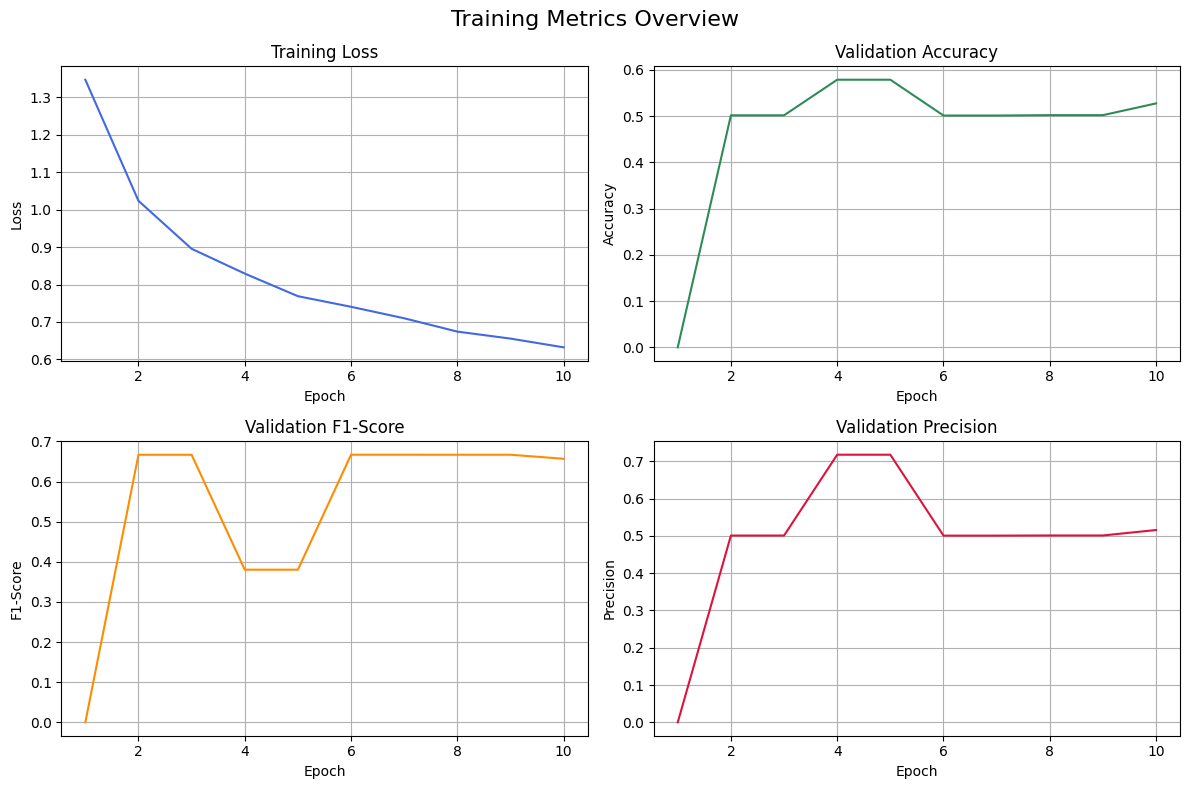

In [16]:
plot_training_dashboard(training_history)

In [17]:
# Cell: Complete Test Set Evaluation
def training_evaluation(model, graph, batch_size=512):
    """
    Complete test set evaluation with:
    - Binary classification metrics
    - Type classification metrics
    - Confusion matrix
    - Per-class performance
    """
    print("COMPREHENSIVE TEST SET EVALUATION")
    print("—"*33, "\n")
    
    model.eval()
    test_edges = graph['edge_index'][:, graph['test_mask']]
    test_labels_bin = graph['y_binary'][graph['test_mask']]
    test_labels_type = graph['y_type'][graph['test_mask']]
    
    test_loader = DataLoader(
        TensorDataset(test_edges.t(), 
                     torch.stack([test_labels_bin, test_labels_type], dim=1)),
        batch_size=batch_size, shuffle=False
    )
    
    full_adj = graph['edge_index'].to(DEVICE)
    x_v1, x_v2, x_v3 = graph['x_v1'].to(DEVICE), graph['x_v2'].to(DEVICE), graph['x_v3'].to(DEVICE)
    
    all_preds_bin, all_probs_bin, all_trues_bin = [], [], []
    all_preds_type, all_trues_type = [], []
    
    with torch.no_grad():
        with autocast(DEVICE_TYPE):
            node_emb = model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
        
        for batch_edges, batch_labels in test_loader:
            batch_edges = batch_edges.t().to(DEVICE)
            p_bin, p_type = model.forward_edges_from_emb(node_emb, batch_edges)
            
            # Binary predictions
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(p_bin, dim=1).cpu().numpy()
            all_preds_bin.extend(preds)
            all_probs_bin.extend(probs)
            all_trues_bin.extend(batch_labels[:, 0].numpy())
            
            # Type predictions (only for positive samples)
            type_preds = torch.argmax(p_type, dim=1).cpu().numpy()
            all_preds_type.extend(type_preds)
            all_trues_type.extend(batch_labels[:, 1].numpy())
    
    # Convert to arrays
    y_true_bin = np.array(all_trues_bin)
    y_pred_bin = np.array(all_preds_bin)
    y_prob_bin = np.array(all_probs_bin)
    y_true_type = np.array(all_trues_type)
    y_pred_type = np.array(all_preds_type)
    
    # 1. BINARY CLASSIFICATION
    print("1. BINARY CLASSIFICATION (Interaction: Yes/No)")
    print(f"{'-'*46}")
    
    acc = accuracy_score(y_true_bin, y_pred_bin)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    
    try:
        roc_auc = roc_auc_score(y_true_bin, y_prob_bin)
    except:
        roc_auc = float('nan')
    
    print(f"• Accuracy:      {acc:.4f}  {'(✓)' if acc >= 0.90 else '⚠  (Target: 0.90)'}")
    print(f"• F1 Score:      {f1:.4f}  {'(✓)' if f1 >= 0.85 else '⚠  (Target: 0.85)'}")
    print(f"• Precision:     {prec:.4f}")
    print(f"• Recall:        {rec:.4f}  {'(✓)' if rec >= 0.85 else '⚠  (Important: catch interactions!)'}")
    print(f"• ROC-AUC:       {roc_auc:.4f}")
    
    # Confusion Matrix

    cm = confusion_matrix(y_true_bin, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\n1.2 CONFUSION MATRIX:")
    print(f"-"*61)
    print(f"| {' '*16}| Predicted: No Int | Predicted: Interact |")
    print(f"| Actual No Int   | {tn:6d}{' '*12}|{fp:6d} {' '*14}|")
    print(f"| Actual Interact | {fn:6d}{' '*12}|{tp:6d} {' '*14}|")
    print(f"-"*61)
    print(f"• True Positives:  {tp:6d}  (Correctly detected interactions)")
    print(f"• False Positives: {fp:6d}  (False alarms - safe but flagged)")
    print(f"• False Negatives: {fn:6d}  (⚠ CRITICAL: Missed interactions!)")
    print(f"• True Negatives:  {tn:6d}  (Correctly identified safe)")
    
    # 2. INTERACTION TYPES CLASSIFICATION
    print("\n\n2. TYPE CLASSIFICATION (Which interaction type?)")
    print(f"{'-'*48}")
    
    # Filter to only positive samples (where type is meaningful)
    pos_mask = y_true_bin == 1
    if pos_mask.sum() > 0:
        y_true_type_pos = y_true_type[pos_mask]
        y_pred_type_pos = y_pred_type[pos_mask]
        
        type_acc = accuracy_score(y_true_type_pos, y_pred_type_pos)
        type_f1 = f1_score(y_true_type_pos, y_pred_type_pos, average='weighted', zero_division=0)
        
        print(f"• 'Type' Accuracy: {type_acc:.4f}")
        print(f"• 'Type' F1 Score: {type_f1:.4f}")
        print(f"• Total 'Types': {len(np.unique(y_true_type_pos))} unique types in test set")
        
        # Top 5 most common types
        from collections import Counter
        type_counts = Counter(y_true_type_pos)
        print(f"\n• Top 5 Most Common Interaction Types:")
        for type_id, count in type_counts.most_common(5):
            type_name = graph['encoder'].inverse_transform([type_id])[0]
            accuracy = (y_pred_type_pos[y_true_type_pos == type_id] == type_id).mean()
            print(f"  - Type {type_name}: {count:4d} samples, {accuracy:.2%} accuracy")
    
    return {
        'binary': {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc_auc},
        'type': {'accuracy': type_acc, 'f1': type_f1} if pos_mask.sum() > 0 else {},
        'confusion_matrix': cm
    }

# Run comprehensive evaluation
test_results = training_evaluation(trained_model, graph)

COMPREHENSIVE TEST SET EVALUATION
————————————————————————————————— 

1. BINARY CLASSIFICATION (Interaction: Yes/No)
----------------------------------------------
• Accuracy:      0.5016  ⚠  (Target: 0.90)
• F1 Score:      0.6669  ⚠  (Target: 0.85)
• Precision:     0.5008
• Recall:        0.9978  (✓)
• ROC-AUC:       0.6019

1.2 CONFUSION MATRIX:
-------------------------------------------------------------
|                 | Predicted: No Int | Predicted: Interact |
| Actual No Int   |    309            | 57234               |
| Actual Interact |    128            | 57414               |
-------------------------------------------------------------
• True Positives:   57414  (Correctly detected interactions)
• False Positives:  57234  (False alarms - safe but flagged)
• False Negatives:    128  (⚠ CRITICAL: Missed interactions!)
• True Negatives:     309  (Correctly identified safe)


2. TYPE CLASSIFICATION (Which interaction type?)
------------------------------------------------
•

## Saving Model Logs and Metadata

In [18]:
# Prepare log entry
current_log = {
    "date": TIMESTAMP,
    "total_training_duration": training_history["training_duration"],
    "config": CONFIG,
    "training_metadata": {
        "Training Loss": round(training_history["train_loss"][-1], 3),
        "Validation Accuracy": round(training_history["val_acc"][-1], 3),
        "Validation F1-Score": round(training_history["val_f1"][-1], 3),
        "Validation Precision": round(training_history["val_precision"][-1], 3),
        "Validation Recall": round(training_history["val_recall"][-1], 3),
    }
}

#  Define file path
log_file = f"{MODEL_METADATA_PATH}.json"

#  Ensure directory exists
os.makedirs(os.path.dirname(log_file), exist_ok=True)

#  Load existing logs if file exists
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        try:
            logs_list = json.load(f)
            if not isinstance(logs_list, list):
                logs_list = []
        except json.JSONDecodeError:
            logs_list = []
else:
    logs_list = []

#  Append new log
logs_list.append(current_log)

# 6️Save file
with open(log_file, "w") as f:
    json.dump(logs_list, f, indent=4)

print(f"(✓) Log successfully saved to {log_file}!")

(✓) Log successfully saved to models/AushadiNet_GATv2-metadata_18_Feb_16-22.json!


In [19]:
# --- CLINICAL MAPPING ---
TYPE_MEANINGS = {
    48: "Metabolism Inhibition (High Risk)",
    46: "Toxicity Accumulation",
    69: "QT Prolongation (Arrhythmia Risk)",
    19: "Bleeding Risk Increase",
    "default": "Unspecified Mechanism"
}

In [20]:
def find_best_threshold(model, graph, device):
    """Find threshold that balances precision/recall for target accuracy."""
    model.eval()
    val_edges = graph['edge_index'][:, graph['val_mask']]
    val_labels_bin = graph['y_binary'][graph['val_mask']]

    val_loader = DataLoader(
        TensorDataset(val_edges.t(), val_labels_bin.unsqueeze(1)),
        batch_size=1024, shuffle=False
    )

    all_probs, all_trues = [], []
    with torch.no_grad():
        with autocast(device.type):
            node_emb = model.get_node_embeddings(
                graph['x_v1'].to(device), graph['x_v2'].to(device),
                graph['x_v3'].to(device), graph['edge_index'].to(device)
            )
        for batch_edges, batch_y in val_loader:
            p_bin, _ = model.forward_edges_from_emb(node_emb, batch_edges.t().to(device))
            probs = torch.softmax(p_bin, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_trues.extend(batch_y.squeeze().numpy())

    y_true = np.array(all_trues)
    y_prob = np.array(all_probs)

    print(f"\n{'—'*55}")
    print(f"{'Thresh':<8} | {'Acc':<8} | {'F1':<8} | {'Prec':<8} | {'Rec':<8}")
    print(f"{'—'*55}")

    best_acc, best_thresh = 0, 0.5
    for thresh in np.arange(0.3, 0.75, 0.05):
        preds = (y_prob >= thresh).astype(int)
        acc  = accuracy_score(y_true, preds)
        f1   = f1_score(y_true, preds, zero_division=0)
        prec = precision_score(y_true, preds, zero_division=0)
        rec  = recall_score(y_true, preds, zero_division=0)
        marker = " ← best acc" if acc > best_acc else ""
        print(f"  {thresh:.2f}   | {acc:.4f}  | {f1:.4f}  | {prec:.4f}  | {rec:.4f}{marker}")
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh

    print(f"{'—'*55}")
    print(f"Best threshold: {best_thresh:.2f} → Accuracy: {best_acc:.4f}")
    return best_thresh

# Cell 8 — paste exactly here, then run:
BEST_THRESHOLD = find_best_threshold(model, graph, DEVICE)
print(f"\nUse this threshold for all predictions: {BEST_THRESHOLD:.2f}")


———————————————————————————————————————————————————————
Thresh   | Acc      | F1       | Prec     | Rec     
———————————————————————————————————————————————————————
  0.30   | 0.5007  | 0.6669  | 0.5003  | 0.9997 ← best acc
  0.35   | 0.5009  | 0.6670  | 0.5005  | 0.9996 ← best acc
  0.40   | 0.5011  | 0.6670  | 0.5005  | 0.9994 ← best acc
  0.45   | 0.5014  | 0.6670  | 0.5007  | 0.9989 ← best acc
  0.50   | 0.5015  | 0.6668  | 0.5008  | 0.9978 ← best acc
  0.55   | 0.5019  | 0.6668  | 0.5010  | 0.9966 ← best acc
  0.60   | 0.5026  | 0.6668  | 0.5013  | 0.9953 ← best acc
  0.65   | 0.5029  | 0.6664  | 0.5015  | 0.9927 ← best acc
  0.70   | 0.5034  | 0.6653  | 0.5017  | 0.9873 ← best acc
———————————————————————————————————————————————————————
Best threshold: 0.70 → Accuracy: 0.5034

Use this threshold for all predictions: 0.70


In [21]:
# Prediction Function

def predict_cardio_interaction_safe(drug_a_id, drug_b_id, model, graph, threshold=0.5):
    """
    Enhanced prediction with complete output:
    - Binary prediction (0 or 1)
    - Probability of interaction
    - Predicted interaction type (always shown)
    - Confidence level
    """
    model.eval()
    
    if drug_a_id not in graph['drug_map'] or drug_b_id not in graph['drug_map']:
        print("⚠ Error: Drug IDs appear to be incorrect! Please check.")
        return None
        
    u = graph['drug_map'][drug_a_id]
    v = graph['drug_map'][drug_b_id]
    
    query_node_indices = torch.tensor([u, v], dtype=torch.long)
    
    # Extract 1-hop subgraph
    subset, edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=query_node_indices, 
        num_hops=1, 
        edge_index=graph['edge_index'], 
        relabel_nodes=True
    )
    
    subgraph_u = mapping[0]
    subgraph_v = mapping[1]
    query_edge = torch.tensor([[subgraph_u], [subgraph_v]], device=DEVICE)
    
    # Get features
    x_v1 = graph['x_v1'][subset].to(DEVICE)
    x_v2 = graph['x_v2'][subset].to(DEVICE)
    x_v3 = graph['x_v3'][subset].to(DEVICE)
    edge_index = edge_index.to(DEVICE)
    
    with torch.no_grad():
        # Get predictions
        logits_bin, logits_type = model(x_v1, x_v2, x_v3, edge_index, query_edge)
        
        # Binary prediction
        probs_bin = torch.softmax(logits_bin, dim=1)[0]  # [prob_no_interaction, prob_interaction]
        prob_interaction = probs_bin[1].item()
        binary_pred = 1 if prob_interaction > threshold else 0
        
        # Type prediction (always compute, even if binary=0)
        probs_type = torch.softmax(logits_type, dim=1)[0]
        type_idx = torch.argmax(logits_type, dim=1).item()
        type_prob = probs_type[type_idx].item()
        
        # Get type name
        try:
            type_name = graph['encoder'].inverse_transform([type_idx])[0]
        except:
            type_name = type_idx
    
    # --- REPORT ---
    print(f"\n{'—'*32}")
    print(f"DRUG PAIR INTERACTION PREDICTION:")
    print(f"{'—'*32}\n")
    print(f"• Drug A:                         {drug_a_id}")
    print(f"• Drug B:                         {drug_b_id}")
    print(f"• Prediction:                     {'⚠ YES, Interaction Detected (Not Safe)' if binary_pred == 1 else '(✓) NO, Interaction Detected (Safe)'}")
    print(f"• Binary Result:                  {binary_pred} ({'Interaction' if binary_pred == 1 else 'No Interaction'})")
    print(f"• Interaction Probability:        {prob_interaction:.2%}")
    print(f"• Threshold:                      {threshold:.2f}")
    print(f"• Predicted 'Interaction Type':   {type_name}")
    print(f"• 'Interaction Type' Confidence:  {type_prob:.2%}")
    
    # Get type description if available
    type_desc = TYPE_MEANINGS.get(int(type_name) if str(type_name).isdigit() else type_name, 
                                   f"Interaction Type {type_name}")
    print(f"• Description (Effect):           {type_desc}")
    
    print(f"• VERDICT: Doctor and Patients should consult on the drugs (medicines) prescription")       

    
    # Return structured data
    return {
        'binary_prediction': binary_pred,
        'interaction_probability': prob_interaction,
        'predicted_type': int(type_name) if str(type_name).isdigit() else type_name,
        'type_probability': type_prob,
        'drug_a': drug_a_id,
        'drug_b': drug_b_id
    }

# Test cases
print("RUNNING TEST PREDICTIONS...")

# Test 1: Your original example
result1 = predict_cardio_interaction_safe('DB00404', 'DB01114', model, graph)

# Test 2: Try another pair (if available)
# Uncomment if you want to test more pairs:
# result2 = predict_cardio_interaction_safe('DB00181', 'DB00754', model, graph)

RUNNING TEST PREDICTIONS...

————————————————————————————————
DRUG PAIR INTERACTION PREDICTION:
————————————————————————————————

• Drug A:                         DB00404
• Drug B:                         DB01114
• Prediction:                     ⚠ YES, Interaction Detected (Not Safe)
• Binary Result:                  1 (Interaction)
• Interaction Probability:        91.50%
• Threshold:                      0.50
• Predicted 'Interaction Type':   72
• 'Interaction Type' Confidence:  80.05%
• Description (Effect):           Interaction Type 72
• VERDICT: Doctor and Patients should consult on the drugs (medicines) prescription


In [ ]:
def gradient_landscape_3d(model, graph, device, n_steps=20, alpha_range=0.5):
    """
    Plots loss surface around current model weights in 3D.
    Intuition: if your model is in a valley (smooth bowl) = good convergence.
    If it's on a sharp spike = unstable, will generalize poorly.
    """
    base_model = model._orig_mod if hasattr(model, '_orig_mod') else model

    # Sample two random directions in weight space
    # Think of these as two random "axes" to explore the loss landscape
    d1 = [torch.randn_like(p) for p in base_model.parameters()]
    d2 = [torch.randn_like(p) for p in base_model.parameters()]

    # Normalize directions so step sizes are comparable across layers
    d1_norm = sum(d.norm()**2 for d in d1)**0.5
    d2_norm = sum(d.norm()**2 for d in d2)**0.5
    d1 = [d / d1_norm for d in d1]
    d2 = [d / d2_norm for d in d2]

    # Save original weights
    orig_params = [p.data.clone() for p in base_model.parameters()]

    # Sample edges for loss computation
    sample_mask = graph['val_mask']
    edges = graph['edge_index'][:, sample_mask][:, :2000].to(device)
    y_bin = graph['y_binary'][sample_mask][:2000].to(device)
    x_v1 = graph['x_v1'].to(device)
    x_v2 = graph['x_v2'].to(device)
    x_v3 = graph['x_v3'].to(device)
    full_adj = graph['edge_index'].to(device)
    crit = nn.CrossEntropyLoss()

    alphas = np.linspace(-alpha_range, alpha_range, n_steps)
    Z = np.zeros((n_steps, n_steps))

    print("Computing loss surface (this takes ~1 min)...")
    for i, a in enumerate(alphas):
        for j, b in enumerate(alphas):
            # Move weights to position (a, b) in the 2D direction space
            for p, orig, dir1, dir2 in zip(base_model.parameters(), orig_params, d1, d2):
                p.data = orig + a * dir1 + b * dir2

            with torch.no_grad():
                with autocast(device.type):
                    node_emb = base_model.get_node_embeddings(x_v1, x_v2, x_v3, full_adj)
                    pred, _ = base_model.forward_edges_from_emb(node_emb, edges)
                    loss = crit(pred, y_bin)
            Z[i, j] = loss.item()

    # Restore original weights
    for p, orig in zip(base_model.parameters(), orig_params):
        p.data = orig.clone()

    # Plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    X, Y = np.meshgrid(alphas, alphas)

    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85, edgecolor='none')
    ax.scatter([0], [0], [Z[n_steps//2, n_steps//2]],
               color='red', s=100, zorder=5, label='Current model position')

    ax.set_xlabel('Direction 1')
    ax.set_ylabel('Direction 2')
    ax.set_zlabel('Loss')
    ax.set_title('Loss Landscape — Smooth bowl = good training', fontsize=13)
    fig.colorbar(surf, shrink=0.4)
    ax.legend()

    plt.tight_layout()
    plt.savefig('images/gradient_landscape_3d.png', dpi=150)
    plt.show()
    print("Red dot = where your model currently sits in the loss landscape.")
    print("Smooth bowl shape = good. Sharp spikes = unstable training.")

gradient_landscape_3d()